# Como criar uma estratégia de trading com Python

### Indicador usado: RSI

### Estratégia:

Vamos comprar a ação sempre que o RSI for menor do que 30.

Será que dá dinheiro?

# Passo a Passo:


* Passo 1: Escolher um ativo.
* Passo 2: Puxar os dados de cotações no Yahoo finance.
* Passo 3: Calcular os retornos positivos e negativos.
* Passo 4: Separar os retornos positivos dos negativos.
* Passo 5: Calcular a média dos retornos positivos e negativos nos últimos 22 dias
* Passo 6: Calcular o RSI
* Passo 7: Gerar os sinais de compra ou venda
* Passo 8: Observando pontos de compra ao longo do tempo
* Passo 9: Calculando lucros
* Passo 10: Analisando lucros
<br>

    * Qual a média de lucros?
    * Qual a média de perdas?
    * Qual a % de operações vencedoras?
    * Qual expectativa matemática do modelo?
    * Qual retorno acumulado?
    * O retorno acumulado venceu o Buy and Hold na ação?


### Fórmula RSI:

$100 - 100/(1 + mediaRetornosPositivos / mediaRetornosNegativos)$

In [5]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

pd.options.mode.chained_assignment = None

# Passo 1: Escolher um ativo

In [6]:
ativo = 'PETR4.SA'

# Passo 2: Puxar os dados do Yahoo Finance

In [7]:
dados_ativo = yf.download(ativo)

dados_ativo

#tome cuidado com ações muito antigas! As vezes vão ter os dados mas com volume zero. 
#Pegue um período que tenha volume 

C:\Users\adm\AppData\Local\Temp\ipykernel_7828\450498765.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_ativo = yf.download(ativo)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2025-06-25,31.209999,31.540001,31.209999,31.320000,23127700
2025-06-26,31.459999,31.600000,31.309999,31.350000,17227000
2025-06-27,31.209999,31.450001,31.139999,31.389999,16482100
2025-06-30,31.379999,31.490000,31.100000,31.209999,23091100
2025-07-01,31.490000,31.570000,31.260000,31.450001,17014100
2025-07-02,32.049999,32.240002,31.480000,31.580000,28311600
2025-07-03,32.160000,32.389999,31.940001,32.000000,14322300
2025-07-04,32.119999,32.310001,31.969999,32.000000,9356900


<Axes: xlabel='Date'>

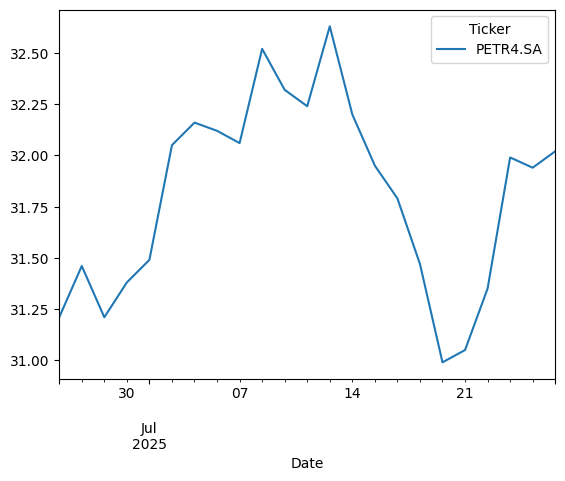

In [8]:
dados_ativo['Close'].plot()

# Passo 3: Calcular os retornos

In [9]:
dados_ativo['retornos'] = dados_ativo['Close'].pct_change().dropna() 

dados_ativo

Price,Close,High,Low,Open,Volume,retornos
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,
Date,,,,,,
2025-06-25,31.209999,31.540001,31.209999,31.320000,23127700,NaN
2025-06-26,31.459999,31.600000,31.309999,31.350000,17227000,0.008010
2025-06-27,31.209999,31.450001,31.139999,31.389999,16482100,-0.007947
2025-06-30,31.379999,31.490000,31.100000,31.209999,23091100,0.005447
2025-07-01,31.490000,31.570000,31.260000,31.450001,17014100,0.003505
2025-07-02,32.049999,32.240002,31.480000,31.580000,28311600,0.017783
2025-07-03,32.160000,32.389999,31.940001,32.000000,14322300,0.003432
2025-07-04,32.119999,32.310001,31.969999,32.000000,9356900,-0.001244


# Passo 4: Separar os retornos positivos dos negativos

In [10]:
retorno = 2

filtrando_retorno = lambda x: x if x > 0 else 0

filtrando_retorno(retorno)

2

In [11]:
dados_ativo['retornos_postivos'] = dados_ativo['retornos'].apply(lambda x: x if x > 0 else 0)
dados_ativo['retornos_negativos'] = dados_ativo['retornos'].apply(lambda x: abs(x) if x < 0 else 0)

dados_ativo

Price,Close,High,Low,Open,Volume,retornos,retornos_postivos,retornos_negativos
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,,,
Date,,,,,,,,
2025-06-25,31.209999,31.540001,31.209999,31.320000,23127700,NaN,0.000000,0.000000
2025-06-26,31.459999,31.600000,31.309999,31.350000,17227000,0.008010,0.008010,0.000000
2025-06-27,31.209999,31.450001,31.139999,31.389999,16482100,-0.007947,0.000000,0.007947
2025-06-30,31.379999,31.490000,31.100000,31.209999,23091100,0.005447,0.005447,0.000000
2025-07-01,31.490000,31.570000,31.260000,31.450001,17014100,0.003505,0.003505,0.000000
2025-07-02,32.049999,32.240002,31.480000,31.580000,28311600,0.017783,0.017783,0.000000
2025-07-03,32.160000,32.389999,31.940001,32.000000,14322300,0.003432,0.003432,0.000000
2025-07-04,32.119999,32.310001,31.969999,32.000000,9356900,-0.001244,0.000000,0.001244


# Passo 5: Calcular a média de retornos positivos e negativos dos últimos 22 dias 

In [12]:
dados_ativo['media_retornos_positivos'] = dados_ativo['retornos_postivos'].rolling(window = 22).mean()
dados_ativo['media_retornos_negativos'] = dados_ativo['retornos_negativos'].rolling(window = 22).mean()

dados_ativo = dados_ativo.dropna()

dados_ativo

Price,Close,High,Low,Open,Volume,retornos,retornos_postivos,retornos_negativos,media_retornos_positivos,media_retornos_negativos
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,,,,,
Date,,,,,,,,,,
2025-07-24,31.940001,32.02,31.65,31.93,17856300,-0.001563,0.000000,0.001563,0.004393,0.003296
2025-07-25,32.020000,32.18,31.91,31.99,4344400,0.002505,0.002505,0.000000,0.004506,0.003296


# Passo 6: Calcular o RSI 

### Fórmula RSI:

$100 - 100/(1 + mediaRetornosPositivos / mediaRetornosNegativos)$

In [13]:
dados_ativo['RSI'] = (100 - 100/
                        (1 + dados_ativo['media_retornos_positivos']/dados_ativo['media_retornos_negativos']))

dados_ativo.head(50)

Price,Close,High,Low,Open,Volume,retornos,retornos_postivos,retornos_negativos,media_retornos_positivos,media_retornos_negativos,RSI
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,,,,,,
Date,,,,,,,,,,,
2025-07-24,31.940001,32.02,31.65,31.93,17856300,-0.001563,0.000000,0.001563,0.004393,0.003296,57.129889
2025-07-25,32.020000,32.18,31.91,31.99,4344400,0.002505,0.002505,0.000000,0.004506,0.003296,57.755423


# Passo 7: Sinais de compra ou venda

In [14]:
dados_ativo.loc[dados_ativo['RSI'] < 30, 'compra'] = 'sim'
dados_ativo.loc[dados_ativo['RSI'] > 30, 'compra'] = 'nao'

dados_ativo

Price,Close,High,Low,Open,Volume,retornos,retornos_postivos,retornos_negativos,media_retornos_positivos,media_retornos_negativos,RSI,compra
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,,,,,,,
Date,,,,,,,,,,,,
2025-07-24,31.940001,32.02,31.65,31.93,17856300,-0.001563,0.000000,0.001563,0.004393,0.003296,57.129889,nao
2025-07-25,32.020000,32.18,31.91,31.99,4344400,0.002505,0.002505,0.000000,0.004506,0.003296,57.755423,nao


In [15]:
datas_compra = []
datas_venda = []

for i in range(len(dados_ativo)):
    print(i)
    
    if "sim" in dados_ativo['compra'].iloc[i]:
        
        datas_compra.append(dados_ativo.iloc[i+1].name)
        
datas_compra

0
1


[]

# A gente vai ter 2 stops de venda:

* RSI acima de 40
* 10 dias de operação

In [16]:
data_compra = []
data_venda = []

for i in range(len(dados_ativo)):
    
    if "sim" in dados_ativo['compra'].iloc[i]:
        
        data_compra.append(dados_ativo.iloc[i+1].name) # +1 porque a gente compra no preço de abertura do dia seguinte.
        
        for j in range(1, 11):
            
            if dados_ativo['RSI'].iloc[i + j] > 40: #vendo se nos proximos 10 dias o RSI passa de 40
                
                data_venda.append(dados_ativo.iloc[i + j + 1].name) #vende no dia seguinte q bater 40
                break
                
            elif j == 10:
                data_venda.append(dados_ativo.iloc[i + j + 1].name)
                
                
        
data_venda

[]

# Passo 8: Observando pontos de compra ao longo do tempo

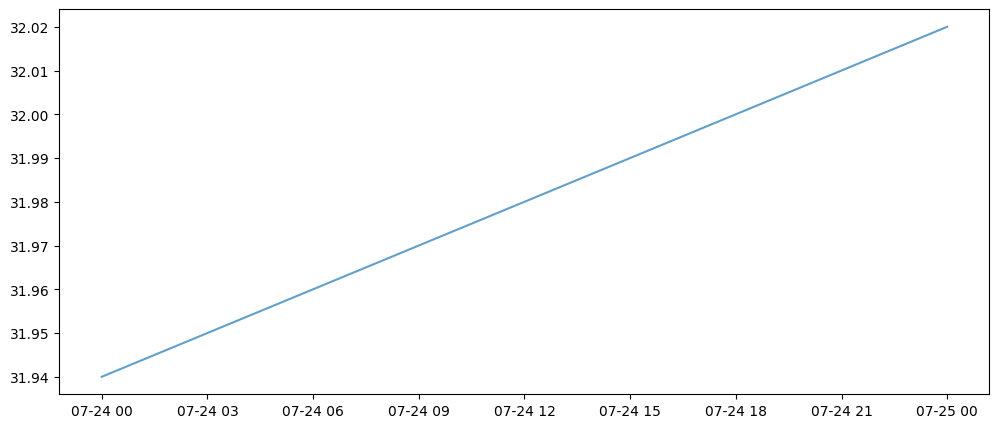

In [18]:
plt.figure(figsize = (12, 5))
plt.scatter(dados_ativo.loc[data_compra].index, dados_ativo.loc[data_compra]['Close'], marker = '^',
            c = 'g')
plt.plot(dados_ativo['Close'], alpha = 0.7)

# Passo 9: Calculando lucros

In [19]:
lucros = dados_ativo.loc[data_venda]['Open'].values/dados_ativo.loc[data_compra]['Open'].values - 1

lucros

array([], shape=(0, 1), dtype=float64)

# Passo 10: Analisando lucros


* Qual a média de lucros?
* Qual a média de perdas?
* Qual a % de operações vencedoras?
* Qual expectativa matemática do modelo?
* Qual retorno acumulado?
* O retorno acumulado venceu o Buy and Hold na ação?

In [20]:
operacoes_vencedoras = len(lucros[lucros > 0])/len(lucros)

operacoes_vencedoras

ZeroDivisionError: division by zero

In [ ]:
media_ganhos = np.mean(lucros[lucros > 0])

media_ganhos * 100

In [ ]:
media_perdas = abs(np.mean(lucros[lucros < 0]))

media_perdas

In [ ]:
expectativa_matematica_modelo = (operacoes_vencedoras * media_ganhos) - ((1 - operacoes_vencedoras) * media_perdas)

expectativa_matematica_modelo * 100

In [ ]:
performance_acumulada = (np.cumprod((1 + lucros)) - 1) 

performance_acumulada * 100

In [ ]:
plt.figure(figsize = (12, 5))
plt.plot(data_compra, performance_acumulada)

In [ ]:
retorno_buy_and_hold = dados_ativo['Adj Close'].iloc[-1]/dados_ativo['Adj Close'].iloc[0] - 1

retorno_buy_and_hold * 100